<a href="https://colab.research.google.com/github/Mamiglia/challenge/blob/master/baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!mkdir data
!gdown 16uZTEYX2cNHZqXNSXA0Kp3uyRi2g7n57
!gdown 1qYKJwU_kkTwzA92zBpJ4V-V53D8tpwRD
!unzip -f test.zip -d data
!unzip train.zip -d data

!git clone https://github.com/Mamiglia/challenge.git

mkdir: cannot create directory ‘data’: File exists
Downloading...
From (original): https://drive.google.com/uc?id=16uZTEYX2cNHZqXNSXA0Kp3uyRi2g7n57
From (redirected): https://drive.google.com/uc?id=16uZTEYX2cNHZqXNSXA0Kp3uyRi2g7n57&confirm=t&uuid=a35677ac-0aff-4af4-8fac-1d85db13c08a
To: /media/nvme/usr/tao/challenge/train.zip
100%|███████████████████████████████████████| 3.70G/3.70G [00:36<00:00, 101MB/s]
Traceback (most recent call last):
  File "/home/tao/nvme/challenge/.venv/bin/gdown", line 4, in <module>
    from gdown.__main__ import main
  File "/media/nvme/usr/tao/challenge/.venv/lib/python3.13/site-packages/gdown/__init__.py", line 6, in <module>
    from .cached_download import cached_download
  File "/media/nvme/usr/tao/challenge/.venv/lib/python3.13/site-packages/gdown/cached_download.py", line 10, in <module>
    import filelock
  File "/media/nvme/usr/tao/challenge/.venv/lib/python3.13/site-packages/filelock/__init__.py", line 20, in <module>
    from .asyncio import (
  

In [31]:
%load_ext autoreload
%autoreload 2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from tqdm import tqdm

from src.common import TRAIN_DATA, TEST_DATA, DEVICE
from src.common import load_data, prepare_train_data, generate_submission

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
# Configuration
MODEL_PATH = "models/mlp_baseline.pth"
EPOCHS = 30
BATCH_SIZE = 256
LR = 0.001
#
class MLP(nn.Module):
    def __init__(self, input_dim=384, output_dim=768, hidden_dim=2048):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            # nn.Linear(hidden_dim, hidden_dim),
            # nn.ReLU(),
            # nn.Dropout(0.2),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


In [28]:

def train_model(model, train_loader, val_loader, device, epochs, lr):
    """Train the MLP model"""
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

        val_loss /= len(val_loader)

        print(f"Epoch {epoch+1}: Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}")

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            Path(MODEL_PATH).parent.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), MODEL_PATH)
            print(f"  ✓ Saved best model (val_loss={val_loss:.6f})")

    return model


In [36]:
# Load data
train_data = load_data(TRAIN_DATA)
X, y = prepare_train_data(train_data)
DATASET_SIZE = len(X)

# Split train/val
# This is done only to verify generalization capabilities, you don't have to
# use a validation set (though we encourage this)
n_train = int(0.9 * len(X))
TRAIN_SPLIT = torch.zeros(len(X), dtype=torch.bool)
TRAIN_SPLIT[:n_train] = 1
X_train, X_val = X[TRAIN_SPLIT], X[~TRAIN_SPLIT]
y_train, y_val = y[TRAIN_SPLIT], y[~TRAIN_SPLIT]

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

Train data: 125000 captions, 25000 images


In [37]:
model = MLP().to(DEVICE)
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Train
print("\n3. Training...")
model = train_model(model, train_loader, val_loader, DEVICE, EPOCHS, LR)

# Load best model for evaluation
model.load_state_dict(torch.load(MODEL_PATH))


   Parameters: 2,362,112

3. Training...


Epoch 1/30: 100%|██████████| 440/440 [00:01<00:00, 269.71it/s]


Epoch 1: Train Loss = 0.445455, Val Loss = 0.419748
  ✓ Saved best model (val_loss=0.419748)


Epoch 2/30: 100%|██████████| 440/440 [00:01<00:00, 263.85it/s]


Epoch 2: Train Loss = 0.406175, Val Loss = 0.407750
  ✓ Saved best model (val_loss=0.407750)


...

Epoch 29/30: 100%|██████████| 440/440 [00:01<00:00, 401.19it/s]


Epoch 29: Train Loss = 0.347347, Val Loss = 0.395736


Epoch 30/30: 100%|██████████| 440/440 [00:01<00:00, 296.00it/s]

Epoch 30: Train Loss = 0.346576, Val Loss = 0.395907


<All keys matched successfully>

## Evaluation

### Visualize

In [44]:
gt_indices_val

array([22500, 22500, 22500, ..., 24999, 24999, 24999], shape=(12500,))

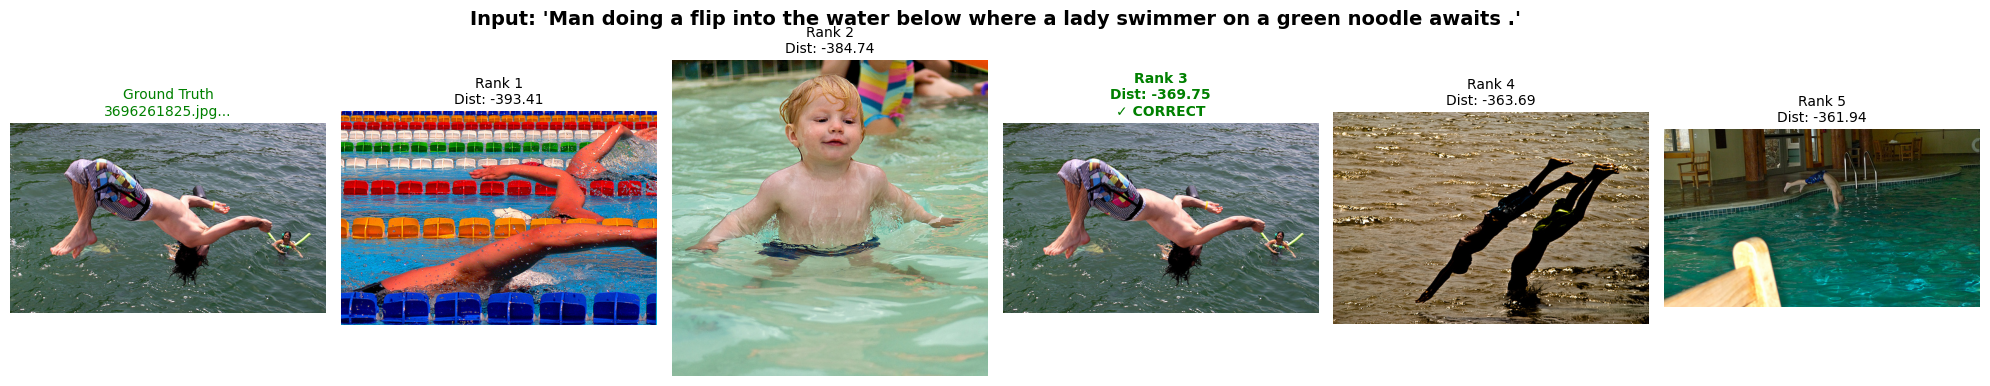

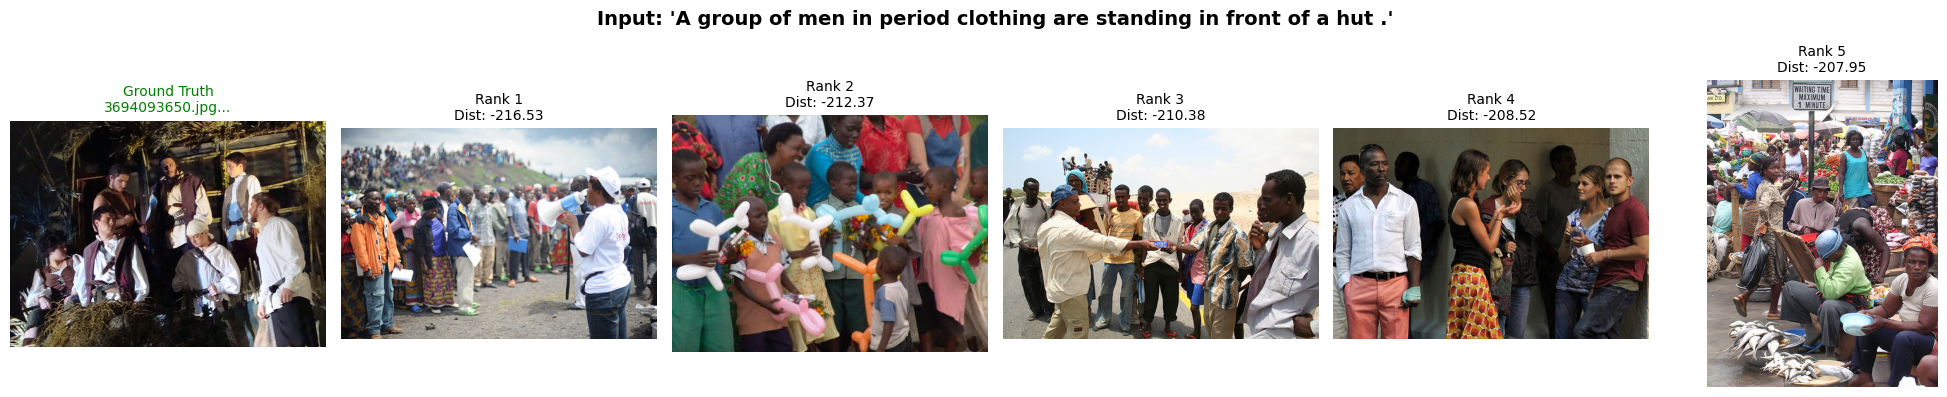

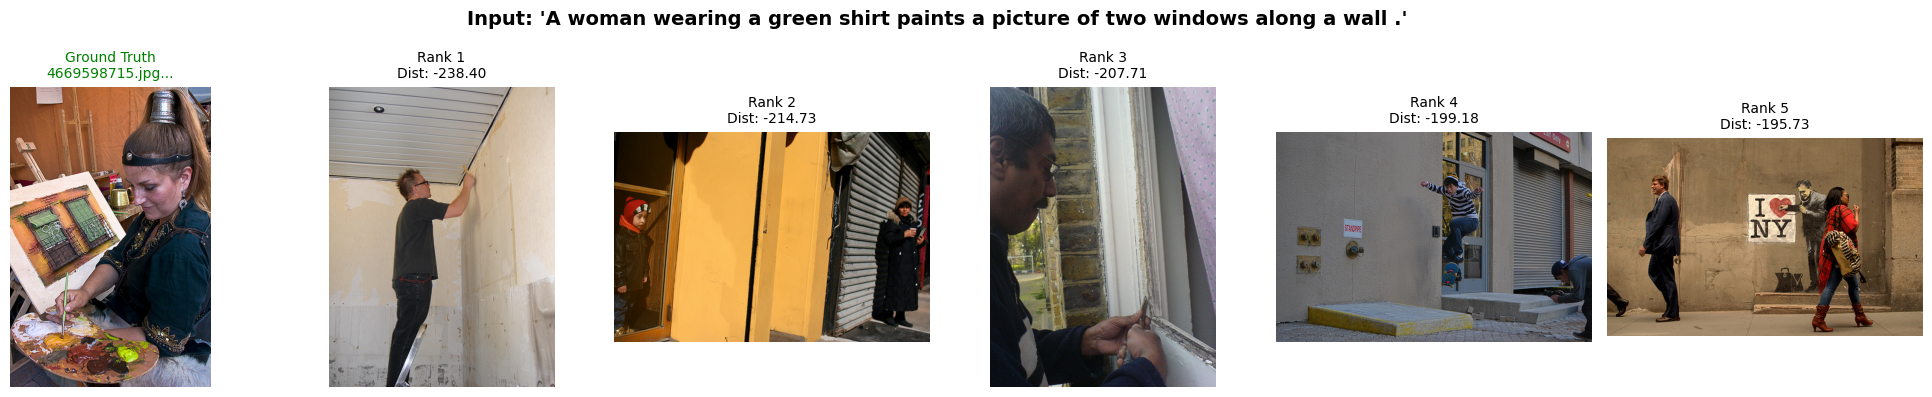

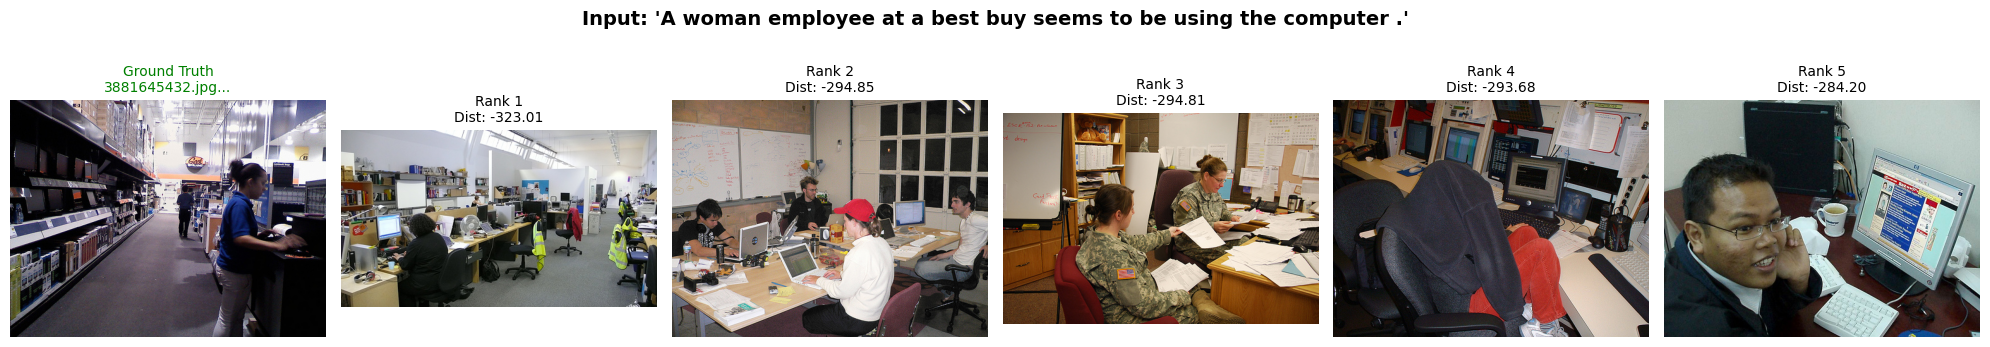

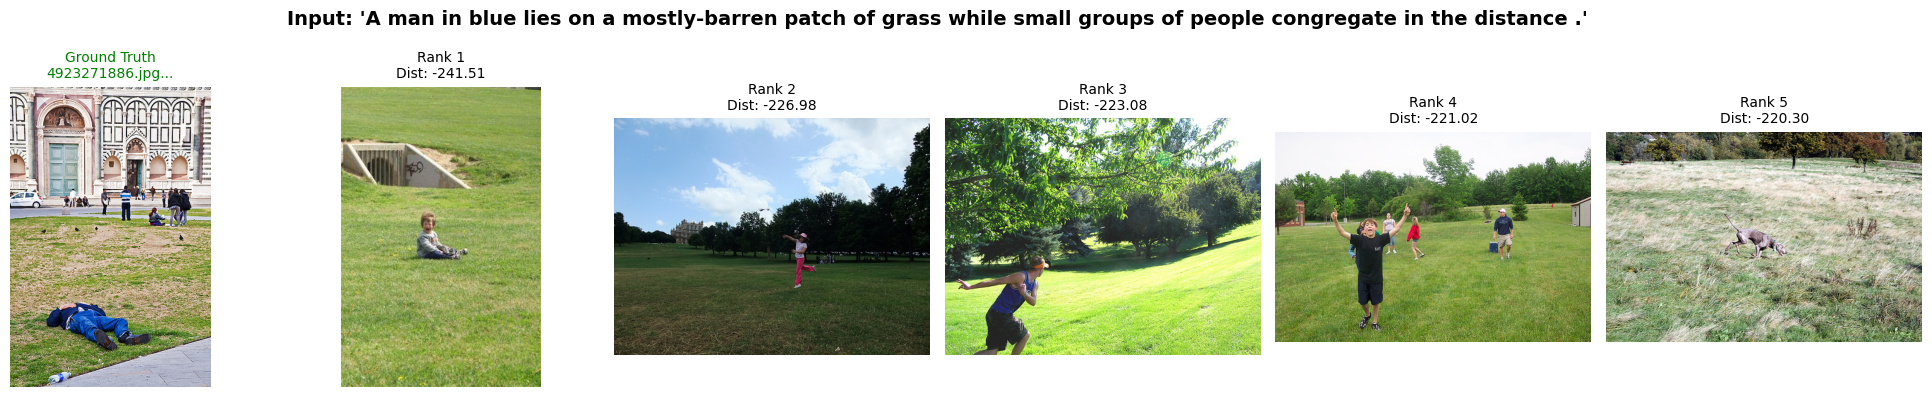

In [67]:
from src.eval import visualize_retrieval
import numpy as np
import torch

VALIDATION_SIZE = len(X_val)

# Validation captions and their image indices
caption_embd_val = X_val
gt_indices_val = train_data["caption2img_idx"][~TRAIN_SPLIT]
caption_text_val = train_data['captions_text'][~TRAIN_SPLIT]

# Extract unique image indices (for val set)
img_idx_val, inv_map = np.unique(gt_indices_val, return_inverse=True)
# inv_map gives exactly the new indices mapping old→new, vectorized!

# Corresponding files and embeddings
img_file_val = np.array(train_data['img_file'])[img_idx_val]
img_embd_val = train_data['img_embd'][img_idx_val]

# Now inv_map provides the updated gt_indices_val
gt_indices_val = inv_map

# Sample and visualize
for i in range(5):
    idx = np.random.randint(0, VALIDATION_SIZE)

    caption_embd = caption_embd_val[idx]
    gt_index = gt_indices_val[idx]
    caption_text = caption_text_val[idx]
    
    with torch.no_grad():
        pred_embds = model(caption_embd.to(DEVICE)).cpu()
        
        visualize_retrieval(
            pred_embds,
            gt_index,
            img_file_val,
            caption_text,
            img_embd_val)


### Eval on validation set

In [65]:
from src.eval import evaluate_retrieval

with torch.inference_mode():
    model.eval()
    translated_embd = model(caption_embd_val.to(DEVICE)).cpu()

    results = evaluate_retrieval(
        translated_embd, img_embd_val, gt_indices_val
    )
print(results)

{'mrr': np.float64(0.002207638241032501), 'ndcg': np.float64(0.0012600010179742976), 'recall_at_1': 0.00064, 'recall_at_3': 0.00128, 'recall_at_5': 0.00192, 'recall_at_10': 0.004, 'recall_at_50': 0.0188, 'l2_dist': 17.139442443847656}


## Submission

In [66]:
test_data = load_data(TEST_DATA)

test_embds = test_data['caption_embd'].float()

with torch.no_grad():
    pred_embds = model(test_embds.to(DEVICE)).cpu()

submission = generate_submission(test_data, pred_embds, DEVICE)
print(f"Model saved to: {MODEL_PATH}")
print(f"Submission saved to: submission.pt")

✓ Saved submission to cuda
Model saved to: models/mlp_baseline.pth
Submission saved to: submission.pt
